# Reward functions and preprocessing etc...

In [1]:
import stable_retro as retro
import gymnasium as gym
from gymnasium import Env
from gymnasium.spaces import MultiBinary, Box
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [ ]:
# start game environment
env = retro.make(game="StreetFighterIISpecialChampionEdition-Genesis-v0")

In [ ]:
# TESTING RENDER ENV
env = retro.make(game="StreetFighterIISpecialChampionEdition-Genesis-v0", render_mode="human")

In [ ]:
# close game environment
env.close()

In [ ]:
env.observation_space

In [ ]:
env.action_space.sample()

In [ ]:
obs, info = env.reset()
terminated = False
truncated = False
for game in range(1):
    while not terminated and not truncated:
        if terminated or truncated:
            obs, info = env.reset()
        env.render()
        obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
        print(reward)
        print(info)

In [ ]:
obs, info = env.reset()

In [42]:
info

{'continuetimer': 10,
 'enemy_matches_won': 2,
 'enemy_health': 0,
 'health': 0,
 'matches_won': 0,
 'score': 40300}

In [20]:
class StreetFighter(Env):
    def __init__(self):
        super().__init__()
        self.observation_space = Box(low=0, high=255, shape=(84, 84, 1), dtype=np.uint8)
        
        self.action_space = MultiBinary(12)

        self.game = retro.make(game="StreetFighterIISpecialChampionEdition-Genesis-v0", use_restricted_actions=retro.Actions.FILTERED)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.game.step(action)
        obs = self.preprocess(obs)

        frame_delta = obs - self.previous_frame
        self.previous_frame = obs

        # reward = info["score"] - self.score
        # self.score = info["score"]

        if info["health"] == 0 and info["enemy_health"] == 0:
            reward = 0
            self.enemy_health = 0
            self.player_health = 0
        else:
            dmg_dealt = self.enemy_health -info["enemy_health"]
            dmg_taken = self.player_health- info["health"]
            self.enemy_health = info["enemy_health"]
            self.player_health = info["health"]
            reward = dmg_dealt - dmg_taken
        

        return obs, reward, terminated, truncated, info


    def render(self, *args, **kwargs):
        self.game.render()

    def reset(self):

        obs, info = self.game.reset()
        obs = self.preprocess(obs)
        self.previous_frame = obs

        
        info = self.game.data.lookup_all()
        self.player_health = info.get("health", 0)
        self.enemy_health = info.get("enemy_health", 0)
        return obs, info

    def preprocess(self, observation):
        gray = cv2.cvtColor(observation, cv2.COLOR_RGB2GRAY)

        resize = cv2.resize(gray, (84,84), interpolation=cv2.INTER_CUBIC)

        channels = np.reshape(resize, (84,84,1))
        return channels


    def close(self):
        self.game.close()

In [8]:
env.close()

In [9]:
env = StreetFighter()

In [13]:
env.observation_space

Box(0, 255, (84, 84, 1), uint8)

In [5]:
env.action_space

MultiBinary(12)

In [23]:
obs, info = env.reset()
terminated = False
truncated = False
pos = 0
neg = 0
for game in range(1):
    while not terminated and not truncated:
        if terminated or truncated:
            obs, info = env.reset()
        env.render()
        obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
        if reward < 0:
            print(reward)
            neg -= reward
        elif reward > 0:
            print(reward)
            pos += reward
    print("Dealt {} damage total, took {} damage total".format(pos, neg))
            
        # print(info["health"], info["enemy_health"])
        

-22
-31
29
-22
-31
-35
7
-21
-12
-3
38
40
6
30
-30
-30
40
-24
5
18
28
29
17
20
-23
40
39
-24
4
-32
28
-26
-26
-26
-39
-28
19
-26
6
-26
-26
-46
45
-25
-26
6
-2
Dealt 494 damage total, took 662 damage total


In [11]:
obs, info = env.reset()

In [12]:
obs, reward, terminated, truncated, info = env.step(env.action_space.sample())

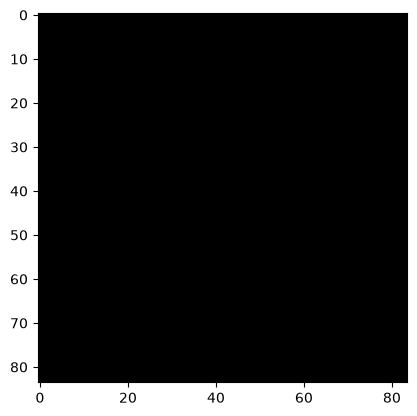

In [40]:
plt.imshow(cv2.cvtColor(obs, cv2.COLOR_GRAY2RGB))

# Hyperparameters

In [2]:
import optuna
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack